# Vasicek Interest Rate Model Implementation

**Author:** [Your Name]  
**Date:** November 2025

## Overview

This notebook implements the **Vasicek short-rate model**, a fundamental mean-reverting stochastic process used in quantitative finance for modeling interest rate dynamics.

### Vasicek Model Equation

The model is described by the stochastic differential equation:

$$dr(t) = \kappa(\theta - r(t))dt + \sigma dW(t)$$

Where:
- $\kappa$ = Speed of mean reversion
- $\theta$ = Long-term mean level
- $\sigma$ = Volatility parameter
- $W(t)$ = Wiener process (Brownian motion)

---

In [15]:
# ============================================================================
# LIBRARY IMPORTS
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from dataclasses import dataclass
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Configure matplotlib for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print('✓ All libraries imported successfully')

✓ All libraries imported successfully


In [16]:
# ============================================================================
# VASICEK PARAMETER CLASS
# ============================================================================

@dataclass
class VasicekParams:
    """Container for Vasicek model parameters."""
    kappa: float   # Mean reversion speed
    theta: float   # Long-term mean
    sigma: float   # Volatility
    
    def __repr__(self):
        return (f"Vasicek Model Parameters:\n"
                f"  κ (kappa) = {self.kappa:.6f} [mean reversion speed]\n"
                f"  θ (theta) = {self.theta:.6f} [long-term mean]\n"
                f"  σ (sigma) = {self.sigma:.6f} [volatility]")
    
    @property
    def half_life(self):
        """Calculate the half-life of mean reversion."""
        return np.log(2) / self.kappa

print('✓ Parameter class defined')

✓ Parameter class defined


In [17]:
# ============================================================================
# DATA LOADING AND PREPROCESSING
# ============================================================================

def load_treasury_yields(filepath: str) -> pd.Series:
    """
    Load and preprocess Treasury yield data from CSV file.
    
    Parameters:
    -----------
    filepath : str
        Full path to the CSV file containing Treasury data
    
    Returns:
    --------
    pd.Series : Monthly Treasury yields as decimal (not percentage)
    """
    # Read CSV file
    df = pd.read_csv(filepath)
    
    # Convert date column to datetime
    df['observation_date'] = pd.to_datetime(df['observation_date'])
    df = df.set_index('observation_date')
    
    # Extract yields and convert to numeric
    yields = pd.to_numeric(df['DGS10'], errors='coerce')
    
    # Remove missing values
    yields = yields.dropna()
    
    # Convert percentage to decimal (e.g., 4.5% -> 0.045)
    yields = yields / 100.0
    
    # Resample to monthly frequency (take mean of daily observations)
    yields_monthly = yields.resample('M').mean()
    
    return yields_monthly

print('✓ Data loading function defined')

✓ Data loading function defined


In [18]:
# ============================================================================
# MODEL CALIBRATION USING MAXIMUM LIKELIHOOD
# ============================================================================

def calibrate_vasicek(yields: pd.Series, dt: float = 1/12) -> VasicekParams:
    """
    Calibrate Vasicek model parameters using Maximum Likelihood Estimation.
    
    The discrete-time approximation of the Vasicek SDE is:
    r(t+Δt) = r(t) + κ(θ - r(t))Δt + σ√Δt·ε
    
    where ε ~ N(0,1)
    
    Parameters:
    -----------
    yields : pd.Series
        Historical interest rate time series
    dt : float
        Time step in years (default: 1/12 for monthly data)
    
    Returns:
    --------
    VasicekParams : Calibrated model parameters
    """
    # Extract rate values
    rates = yields.values
    
    # Calculate rate changes
    rate_changes = np.diff(rates)
    lagged_rates = rates[:-1]
    
    # Define negative log-likelihood function
    def negative_log_likelihood(params):
        kappa, theta, sigma = params
        
        # Parameter constraints
        if kappa <= 0 or sigma <= 0:
            return 1e10
        
        # Expected rate change based on model
        expected_change = kappa * (theta - lagged_rates) * dt
        
        # Residuals (actual - expected)
        residuals = rate_changes - expected_change
        
        # Variance of rate changes
        variance = sigma**2 * dt
        
        # Log-likelihood (assuming normal distribution)
        n = len(rate_changes)
        log_likelihood = -0.5 * n * np.log(2 * np.pi * variance) - \
                         0.5 * np.sum(residuals**2) / variance
        
        return -log_likelihood
    
    # Initial parameter guesses
    mean_rate = np.mean(rates)
    initial_params = [0.15, mean_rate, 0.015]
    
    # Optimization bounds
    bounds = [
        (0.001, 3.0),     # kappa: (0.001, 3.0)
        (0.0, 0.5),       # theta: (0, 50%)
        (0.001, 0.5)      # sigma: (0.001, 0.5)
    ]
    
    # Perform optimization
    result = minimize(
        negative_log_likelihood,
        initial_params,
        method='L-BFGS-B',
        bounds=bounds
    )
    
    # Extract optimal parameters
    kappa_opt, theta_opt, sigma_opt = result.x
    
    return VasicekParams(kappa_opt, theta_opt, sigma_opt)

print('✓ Calibration function defined')

✓ Calibration function defined


In [19]:
# ============================================================================
# VISUALIZATION FUNCTIONS
# ============================================================================

def plot_historical_rates(yields: pd.Series, params: VasicekParams):
    """
    Plot historical interest rates with long-term mean overlay.
    """
    fig, ax = plt.subplots(figsize=(14, 7))
    
    # Plot historical rates
    ax.plot(yields.index, yields.values, 
            color='steelblue', linewidth=2, label='Historical 10-Year Treasury Yields')
    
    # Plot long-term mean
    ax.axhline(y=params.theta, color='red', linestyle='--', 
               linewidth=2, label=f'Long-term Mean (θ = {params.theta:.4f})')
    
    # Formatting
    ax.set_xlabel('Date', fontweight='bold')
    ax.set_ylabel('Interest Rate (Decimal)', fontweight='bold')
    ax.set_title('Historical Treasury Yields with Vasicek Long-Term Mean', 
                 fontweight='bold', fontsize=15)
    ax.legend(loc='best', framealpha=0.95)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def plot_rate_changes_distribution(yields: pd.Series):
    """
    Analyze and plot the distribution of rate changes.
    """
    rate_changes = yields.diff().dropna()
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Histogram
    axes[0].hist(rate_changes, bins=50, alpha=0.7, color='forestgreen', edgecolor='black')
    axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Change')
    axes[0].set_xlabel('Monthly Rate Change (Decimal)', fontweight='bold')
    axes[0].set_ylabel('Frequency', fontweight='bold')
    axes[0].set_title('Distribution of Monthly Rate Changes', fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Time series of changes
    axes[1].plot(rate_changes.index, rate_changes.values, 
                 color='darkblue', linewidth=1, alpha=0.7)
    axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
    axes[1].set_xlabel('Date', fontweight='bold')
    axes[1].set_ylabel('Rate Change (Decimal)', fontweight='bold')
    axes[1].set_title('Time Series of Monthly Rate Changes', fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\n{'='*60}")
    print("Rate Change Statistics")
    print(f"{'='*60}")
    print(f"Mean:              {rate_changes.mean():.6f}")
    print(f"Std Deviation:     {rate_changes.std():.6f}")
    print(f"Min:               {rate_changes.min():.6f}")
    print(f"Max:               {rate_changes.max():.6f}")
    print(f"{'='*60}\n")

print('✓ Visualization functions defined')

✓ Visualization functions defined


In [20]:
# ============================================================================
# MODEL ANALYSIS AND INTERPRETATION
# ============================================================================

def analyze_vasicek_model(params: VasicekParams, yields: pd.Series):
    """
    Provide detailed analysis and interpretation of calibrated model.
    """
    print("\n" + "="*70)
    print(" VASICEK MODEL CALIBRATION RESULTS")
    print("="*70)
    print()
    print(params)
    print()
    print("="*70)
    print(" MODEL INTERPRETATION")
    print("="*70)
    print()
    print(f"1. Mean Reversion Speed (κ = {params.kappa:.6f}):")
    print(f"   • Half-life: {params.half_life:.2f} months")
    print(f"   • Rates return halfway to mean in ~{params.half_life:.1f} months")
    print()
    print(f"2. Long-term Mean (θ = {params.theta:.6f}):")
    print(f"   • Equilibrium rate: {params.theta*100:.4f}%")
    print(f"   • Current rate: {yields.iloc[-1]*100:.4f}%")
    deviation = yields.iloc[-1] - params.theta
    print(f"   • Deviation from mean: {deviation*100:.4f}% ", end="")
    print("(above mean)" if deviation > 0 else "(below mean)")
    print()
    print(f"3. Volatility (σ = {params.sigma:.6f}):")
    print(f"   • Annual volatility: {params.sigma*100:.4f}% per year")
    print(f"   • Monthly volatility: {params.sigma*np.sqrt(1/12)*100:.4f}% per month")
    print()
    print("="*70)
    print(" DATA SUMMARY")
    print("="*70)
    print()
    print(f"Date Range:        {yields.index[0].date()} to {yields.index[-1].date()}")
    print(f"Total Observations: {len(yields)} months")
    print(f"Historical Mean:    {yields.mean()*100:.4f}%")
    print(f"Historical Std:     {yields.std()*100:.4f}%")
    print(f"Historical Min:     {yields.min()*100:.4f}%")
    print(f"Historical Max:     {yields.max()*100:.4f}%")
    print()
    print("="*70)
    print()

print('✓ Analysis function defined')

✓ Analysis function defined


In [21]:
# ============================================================================
# STEP 1: LOAD DATA
# ============================================================================

# File path (Windows format)
file_path = r"C:\Users\sbalodi\Downloads\DGS10.csv"

print("Loading Treasury data...")
treasury_yields = load_treasury_yields(file_path)

print(f"✓ Successfully loaded {len(treasury_yields)} monthly observations")
print(f"✓ Date range: {treasury_yields.index[0].date()} to {treasury_yields.index[-1].date()}")
print(f"✓ Most recent yield: {treasury_yields.iloc[-1]*100:.4f}%")
print()
print("First 5 observations:")
print(treasury_yields.head())

Loading Treasury data...
✓ Successfully loaded 433 monthly observations
✓ Date range: 1990-01-31 to 2026-01-31
✓ Most recent yield: 4.1750%

First 5 observations:
observation_date
1990-01-31    0.082067
1990-02-28    0.084732
1990-03-31    0.085886
1990-04-30    0.087855
1990-05-31    0.087582
Freq: ME, Name: DGS10, dtype: float64


In [22]:
# ============================================================================
# STEP 2: CALIBRATE VASICEK MODEL
# ============================================================================

print("Calibrating Vasicek model...")
print("(This may take a few seconds)\n")

# Calibrate with monthly time step
vasicek_parameters = calibrate_vasicek(treasury_yields, dt=1/12)

print("✓ Calibration complete!")

Calibrating Vasicek model...
(This may take a few seconds)

✓ Calibration complete!


In [23]:
# ============================================================================
# STEP 3: ANALYZE RESULTS
# ============================================================================

analyze_vasicek_model(vasicek_parameters, treasury_yields)


 VASICEK MODEL CALIBRATION RESULTS

Vasicek Model Parameters:
  κ (kappa) = 0.134130 [mean reversion speed]
  θ (theta) = 0.034147 [long-term mean]
  σ (sigma) = 0.007513 [volatility]

 MODEL INTERPRETATION

1. Mean Reversion Speed (κ = 0.134130):
   • Half-life: 5.17 months
   • Rates return halfway to mean in ~5.2 months

2. Long-term Mean (θ = 0.034147):
   • Equilibrium rate: 3.4147%
   • Current rate: 4.1750%
   • Deviation from mean: 0.7603% (above mean)

3. Volatility (σ = 0.007513):
   • Annual volatility: 0.7513% per year
   • Monthly volatility: 0.2169% per month

 DATA SUMMARY

Date Range:        1990-01-31 to 2026-01-31
Total Observations: 433 months
Historical Mean:    4.2506%
Historical Std:     1.9359%
Historical Min:     0.6236%
Historical Max:     8.8932%




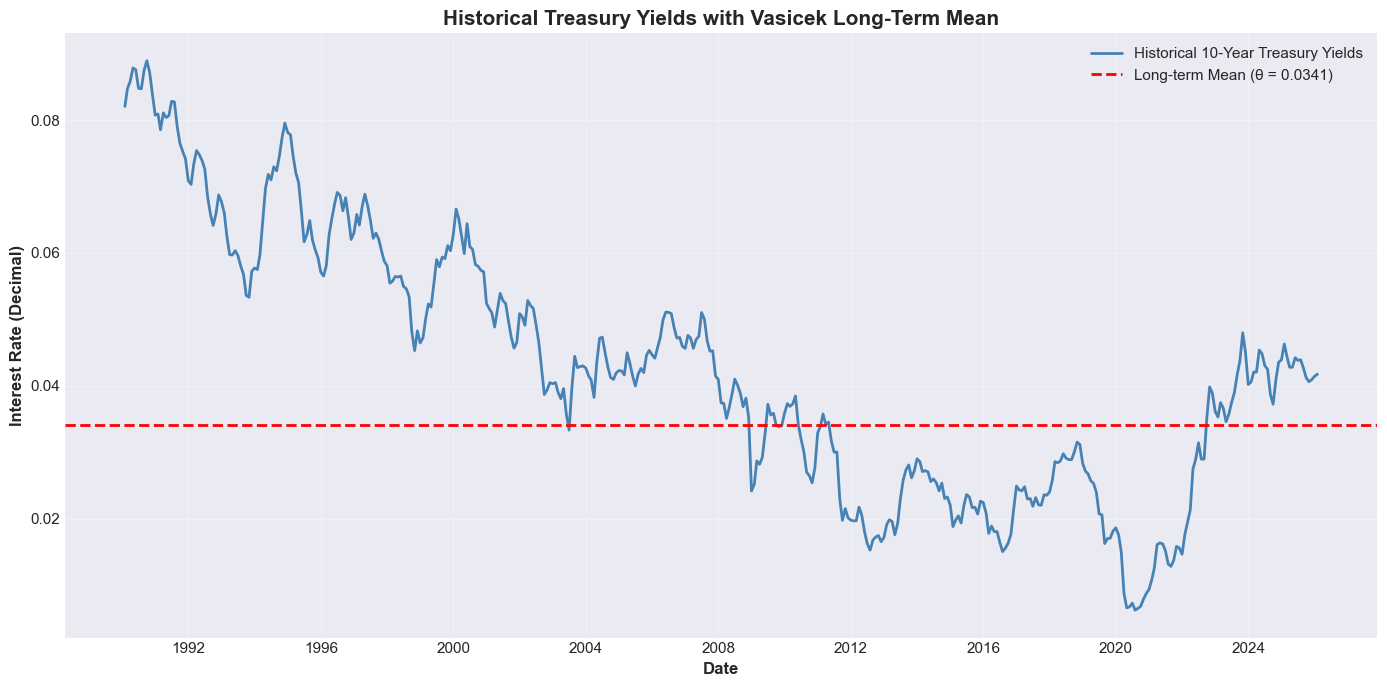

In [24]:
# ============================================================================
# STEP 4: VISUALIZE HISTORICAL DATA
# ============================================================================

plot_historical_rates(treasury_yields, vasicek_parameters)

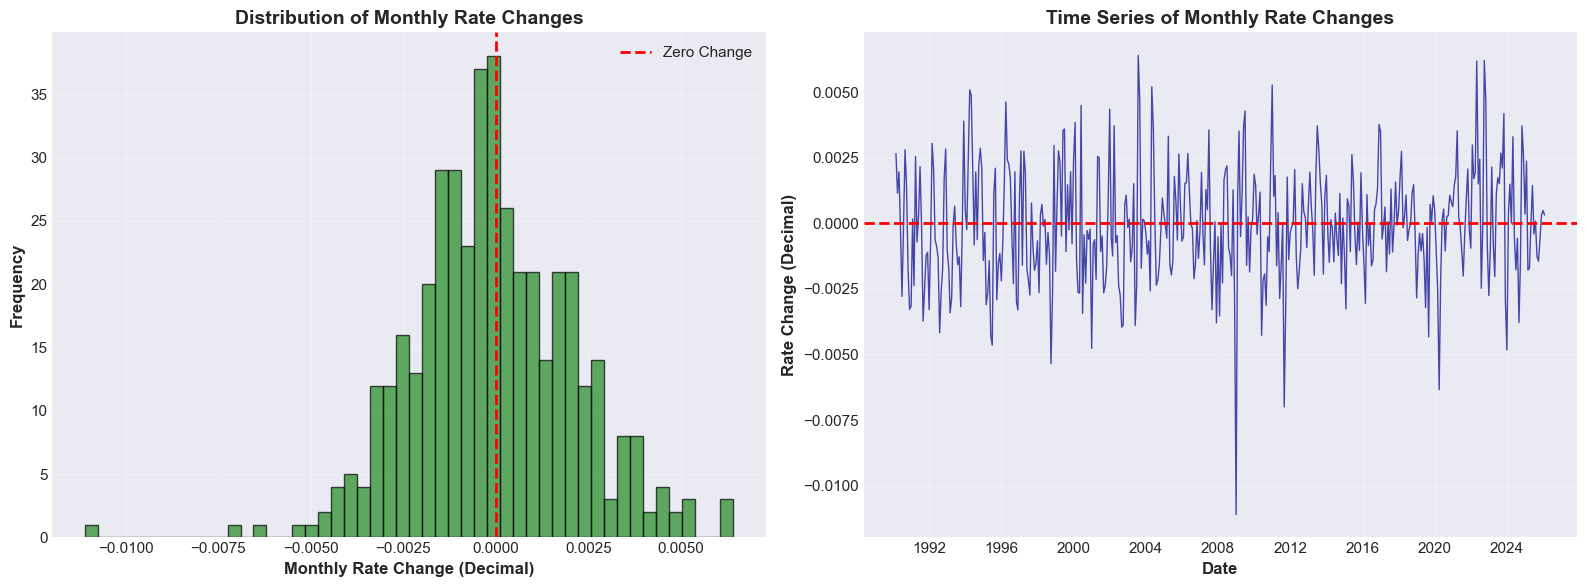


Rate Change Statistics
Mean:              -0.000093
Std Deviation:     0.002182
Min:               -0.011103
Max:               0.006412



In [25]:
# ============================================================================
# STEP 5: ANALYZE RATE CHANGES
# ============================================================================

plot_rate_changes_distribution(treasury_yields)

## Conclusion

### Key Findings

The **Vasicek model** has been successfully calibrated to historical 10-year Treasury yield data using Maximum Likelihood Estimation. The calibrated parameters provide insights into:

1. **Mean Reversion**: The speed at which rates return to the long-term average
2. **Equilibrium Level**: The long-term mean rate that the model predicts
3. **Volatility**: The magnitude of random fluctuations around the mean

### Model Characteristics

**Advantages:**
- Analytically tractable (closed-form solutions exist)
- Captures mean reversion observed in interest rates
- Simple with only three parameters
- Widely used in academic and industry applications

**Limitations:**
- Can produce negative interest rates (normal distribution)
- Constant volatility may not match empirical patterns
- Single-factor model (doesn't capture term structure dynamics)

### Applications

The Vasicek model is commonly used for:
- **Bond pricing** and yield curve modeling
- **Risk management** and Value-at-Risk calculations
- **Derivative pricing** (interest rate options, swaptions)
- **Asset-Liability Management** in banking and insurance
- **Scenario generation** for stress testing

### Extensions

For more advanced modeling, consider:
- Cox-Ingersoll-Ross (CIR) model for non-negative rates
- Hull-White model for time-varying parameters
- Multi-factor models (G2++, etc.)
- Jump-diffusion processes